# Nelder and Mead Downhill Simplex Method

The Nelder and Mead simplex method is a derivative-free optimization technique introduced in 1965. It is especially useful when gradients of the objective function are unavailable or unreliable, and when the goal is to quickly find a working solution rather than a highly efficient one.

## References
1. [Nelder, J.A., and Mead, R. (1965). A simplex method for function minimization. *The Computer Journal*, 7(4), 308–313. ](https://doi.org/10.1093/comjnl/7.4.308)
2. [ Press, William H.; Teukolsky, Saul A.; Vetterling, William T.; Flannery, Brian P. (1986). *Numerical Recipes: The Art of Scientific Computing.* 1ed. New York: Cambridge University Press. pp. 402-406 ISBN 0-521-30811-9.](http://54.243.252.9/ce-5319-webroot/MLBE4CE/chapters/17-optimization/NumericalRecipesinF77-NelderMead.pdf)
3. [SciPy Optimize Documentation: ](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)


## Videos

1. none
---

## Narrative Description

:::{note} 
The narrative that follows is largely paraphrased from Press et. al. (1986).
:::

At its core, the method operates on a geometric structure called a **simplex** — a set of $N+1$ points in an $N$-dimensional space. For example, a simplex in 2D is a triangle; in 3D, it becomes a tetrahedron. Unlike the linear programming simplex method (which shares the name but not the algorithm), this **downhill simplex** method explores the space by reshaping and repositioning the simplex as it seeks a minimum.

### How It Works

The algorithm begins with an initial simplex — a group of $N+1$ points, often generated by taking an initial guess and perturbing it slightly in each coordinate direction:

$$
P_i = P_0 + \lambda e_i
$$

where $e_i$ is a unit vector in the $i$-th direction and $\lambda$ is a user-defined scaling parameter.

The method then repeatedly adjusts the simplex using geometrically intuitive operations:

- **Reflection**: Move the worst-performing vertex across the opposite face to probe a potentially better direction.
- **Expansion**: If reflection leads to a strong improvement, stretch the simplex further in that direction.
- **Contraction**: If reflection doesn’t improve much, try a smaller step inward.
- **Shrinkage**: If all else fails, collapse the simplex toward its best point and try again in a more focused region.

This sequence of moves mimics an **amoeba-like behavior**, squeezing and stretching through the topology of the objective function in search of a minimum.

### Stopping Criteria and Restarts

In multidimensional optimization, there is no simple way to “bracket” a minimum as in one dimension. The algorithm usually stops when:

- The size of the simplex becomes very small (based on distance moved).
- The improvement in objective function value becomes negligible.

However, these criteria can be fooled by anomalies — a single bad step might make it *seem* like convergence. Therefore, it’s usually a good idea to **restart the algorithm from the claimed minimum**, reinitializing the simplex with small perturbations. This helps confirm that the found solution is robust and not an artifact of the initial simplex shape.


- Function calls only
- Needs a starting vector that is non-degenerate

In [1]:
import numpy as np
from scipy.optimize import minimize



def rosen(x):
    """The Rosenbrock function"""
    return sum(100.0*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0)

x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])
res = minimize(rosen, x0, method='nelder-mead',options={'disp': True})

print(res.x)

Optimization terminated successfully.
         Current function value: 0.000066
         Iterations: 141
         Function evaluations: 243
[0.99910115 0.99820923 0.99646346 0.99297555 0.98600385]


## The nelder_mead_minimizer Module
This example uses the `scipy.optimize.minimize` interface with method='Nelder-Mead'.

Nelder-Mead is a derivative-free optimization method that uses a simplex (a geometric figure of n+1 vertices in n dimensions) to search for a minimum.

Advantages:
- Simple to use, no gradient required
- Robust to noise and discontinuities in many cases

Disadvantages:
- May be slower than gradient-based methods
- Not guaranteed to converge for non-smooth functions
- Needs a starting vector that is non-degenerate (you need an initial guess of a simplex that has non-zero hypervolume, and non-infinite function values.

---

## Example 1: Rosenbrock Function

In [2]:
# Example 1
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Define Rosenbrock Function
def rosen(x):
    """
    The Rosenbrock function: a standard test for optimization algorithms.
    f(x) = sum(100*(x[i+1] - x[i]**2)**2 + (1 - x[i])**2 for i in range(n-1))
    """
    return sum(100.0*(x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

# Initial guess (non-degenerate simplex)
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])

# Optimization call
res = minimize(rosen, x0, method='nelder-mead', options={'disp': True})

# Display results
print("Minimum Value        :", res.fun)
print("Optimum at           :", res.x)
print("Function evaluations :", res.nfev)
print("Number of Iterations :", res.nit)

Optimization terminated successfully.
         Current function value: 0.000066
         Iterations: 141
         Function evaluations: 243
Minimum Value        : 6.617481708884532e-05
Optimum at           : [0.99910115 0.99820923 0.99646346 0.99297555 0.98600385]
Function evaluations : 243
Number of Iterations : 141


---

## Plotting 2D Example (Optional Visualization)
To visualize the method's behavior in 2D:

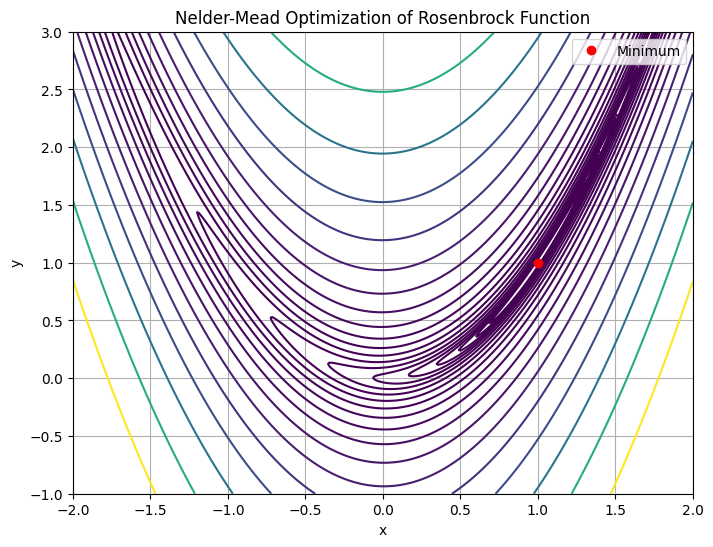

In [3]:
# Define a 2D Rosenbrock for contour plot
def rosen2(xy):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosen2([X, Y])

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(res.x[0], res.x[1], 'ro', label='Minimum')
plt.title("Nelder-Mead Optimization of Rosenbrock Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

An obvious pedagogical improvement would be to modify both the search code and the plotting code so the coordinates of the intermediate "coordinates" are captured as a list and plotted, to show progression from starting guess to the minimum.  

:::{note}  This is a perfect instance of using AI assistant to try the modification for us.  The actual prompt is the above sentance posed as a question: "Can you modify the attached script to .....".  Below are the suggested code modifications :::

### Modify Search Code to Capture Path
You can use the `callback` argument in `scipy.optimize.minimize()` to record each new point visited by the optimizer.  Make sure path is a list defined outside the callback so it accumulates steps. The xk passed to record_path is the current best point.

In [4]:
# Example 1 - Modified to record guess for each step
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Define Rosenbrock Function
def rosen(x):
    """
    The Rosenbrock function: a standard test for optimization algorithms.
    f(x) = sum(100*(x[i+1] - x[i]**2)**2 + (1 - x[i])**2 for i in range(n-1))
    """
    return sum(100.0*(x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

# Define a storage list for the path
rpath = []

def record_path(xk):
    # Each intermediate guess is appended to path
    rpath.append(np.copy(xk))

# Initial guess (non-degenerate simplex)
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])

# Optimization call
res = minimize(rosen, x0, method='nelder-mead', options={'disp': True}, callback=record_path)

# Display results
print("Minimum Value        :", res.fun)
print("Optimum at           :", res.x)
print("Function evaluations :", res.nfev)
print("Number of Iterations :", res.nit)

Optimization terminated successfully.
         Current function value: 0.000066
         Iterations: 141
         Function evaluations: 243
Minimum Value        : 6.617481708884532e-05
Optimum at           : [0.99910115 0.99820923 0.99646346 0.99297555 0.98600385]
Function evaluations : 243
Number of Iterations : 141


### Modify 2D Plot to Show Path
Let’s adapt the plot section to use this path list, assuming we’re doing a 2D case (i.e., len(x0)==2):

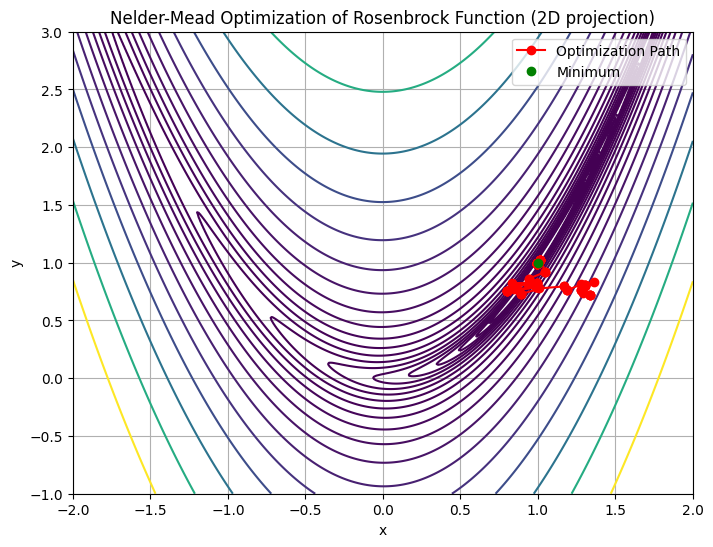

In [7]:
# Define a 2D Rosenbrock for contour plot
def rosen2(xy):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosen2([X, Y])

# Only keep first two dimensions of each path entry
path2d = np.array([p[:2] for p in rpath])  # Adjust if higher dimensions

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='viridis')

# Plot path
plt.plot(*path2d.T, 'ro-', linewidth=1.5, label='Optimization Path')
plt.plot(res.x[0], res.x[1], 'go', label='Minimum')
plt.title("Nelder-Mead Optimization of Rosenbrock Function (2D projection)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


Thus we can visualize the progression from initial guess, to the optimizers "solution".  Naturally in higher dimensions, this visualization becomes much harder (anything beyond 4 dimensions is hard to visualize).  But for feature engineering even subsets of 3-4 dimensions can be very useful.

---

## Discussion Questions
- How did the Nelder-Mead method perform in terms of iterations and function evaluations?
- What happens if we change the starting guess?
- Which types of civil engineering models could benefit from derivative-free methods like Nelder-Mead?

---

## Try It!
Try replacing the Rosenbrock function with a model from your field, such as a calibration function for inflow-outflow data, or another surrogate objective in hydrology or transport analysis.